In [2]:
import numpy as np
from bayesian_wrapper import generateCrossSection, runBolsig, convertBolsigData, refcrs
from swarmData import swarmData, swarmDatasets
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

### Test GenerateCrossSection

In [ ]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
testcrs = GenerateCrossSection(theta_ref)

plt.figure(1)
for c in refcrs.crs:
    if ((c.colType==0) or (c.colType==1)):
        plt.loglog(c.data[:,0],c.data[:,1],'-k')
for c in testcrs.crs:
    if ((c.colType==0) or (c.colType==1)):
        plt.loglog(c.data[:,0],c.data[:,1],'--b')

### Test RunBolsig

In [ ]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
testcrs = GenerateCrossSection(theta_ref,filename="./bayesian-bolsig/crs/test-crs.txt")

outputs = RunBolsig(dataDir="./bayesian-bolsig")

### Run time measurements

In [ ]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])

from time import perf_counter
times = np.zeros((3,))

Ntest = 10
for k in range(Ntest):
    tic = perf_counter()
    testcrs = GenerateCrossSection(theta_ref,filename="./bayesian-bolsig/crs/test-crs.txt")
    toc = perf_counter()
    times[0] += toc - tic

    outputs, times_bolsig = RunBolsig(dataDir="./bayesian-bolsig",check_time=True)
    times[1:] += times_bolsig
times /= Ntest
print(times)

### Test comparison

In [ ]:
filename = "../swarm/" + swarmDatasets[1] + ".txt"
testData = swarmData(filename)

theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
testcrs = GenerateCrossSection(theta_ref,filename="./bayesian-bolsig/crs/test-crs.txt")
outputs = RunBolsig(dataDir="./bayesian-bolsig")

bolsigData = ConvertBolsigData(testData.datasets[0],outputs[1])

for k, var in enumerate(testData.datasets[0].variables):
    if ( (var == 'E/N') or (var[-4:] == '-rms') or (var[-4:] == '-max') ): continue
    print(var)
    plt.figure(k)
    plt.errorbar(testData.datasets[0].variables['E/N'],testData.datasets[0].variables[var],yerr=testData.datasets[0].variables[var+'-rms'],fmt='.')
    plt.loglog(testData.datasets[0].variables['E/N'],bolsigData[var],'-r')

## probability evaluation

In [ ]:
expDatasets = []
for expDatafile in swarmDatasets:
    filename = "../swarm/" + expDatafile + ".txt"
    expDatasets += [swarmData(filename)]

def log_prior(theta):
    theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    
def log_likelihood(theta):
    # compute log-normal probability
    testcrs = GenerateCrossSection(theta,filename="./bayesian-bolsig/crs/test-crs.txt")
    outputs = RunBolsig(dataDir="./bayesian-bolsig")

    lk = 0.0
    for k, expData in enumerate(expDatasets): # per each experiment
        for expDataTable in expData.datasets: # per each table in an experiment
            bolsigData = ConvertBolsigData(expDataTable,outputs[k])
            for kk, var in enumerate(expDataTable.variables): # per each variable in a table
                if ( (var == 'E/N') or (var[-4:] == '-rms') or (var[-4:] == '-max') ): continue
                y = expDataTable.variables[var]
                yerr = expDataTable.variables[var+'-rms']
                sigma2 = np.log(1.0 + yerr / y) ** 2
                pred_y = bolsigData[var]
                lk += - 0.5 * np.sum( (np.log(y) - np.log(pred_y)) ** 2 / sigma2 )
                lk += - 0.5 * np.sum( np.log(2.0*np.pi*sigma2) )

    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
import emcee
nwalkers = 9
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)
sampler.run_mcmc(pos, 1500, progress=True);

tau = sampler.get_autocorr_time()
print(tau)

### Test writing input file

In [ ]:
from input_writer import expConfigs, writeInputFile

filename = './bayesian-bolsig/input/test-input.dat'
crsFile = 'test-crs.txt'
outputfile = 'test-output.dat'

writeInputFile(filename,expConfigs["AlAminLucas1987"],crsFile,outputfile)

## MPIPool MCMC sampling

In [2]:
from bayesian_wrapper import log_likelihood_parallel

def log_prior(theta):
    theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
    sigma2 = ( 0.5 * theta_ref )**2
    return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood_parallel(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
import emcee
from mpi4py import MPI
comm = MPI.COMM_WORLD
pool = MPI
nwalkers = 9
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)
sampler.run_mcmc(pos, 1500, progress=True);

tau = sampler.get_autocorr_time()
print(tau)

In [10]:
import emcee
filename = "./bayesian-bolsig/elastic.h5"

reader = emcee.backends.HDFBackend(filename)
tau = reader.get_autocorr_time(tol=0)
print(tau)
burnin = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))
samples = reader.get_chain(discard=burnin, flat=True, thin=thin)
size = reader.get_chain(flat=True).shape
print(size)

[335.35746237 405.37430503 153.87417671 294.72692911]
(151340, 4)


<Figure size 432x288 with 0 Axes>

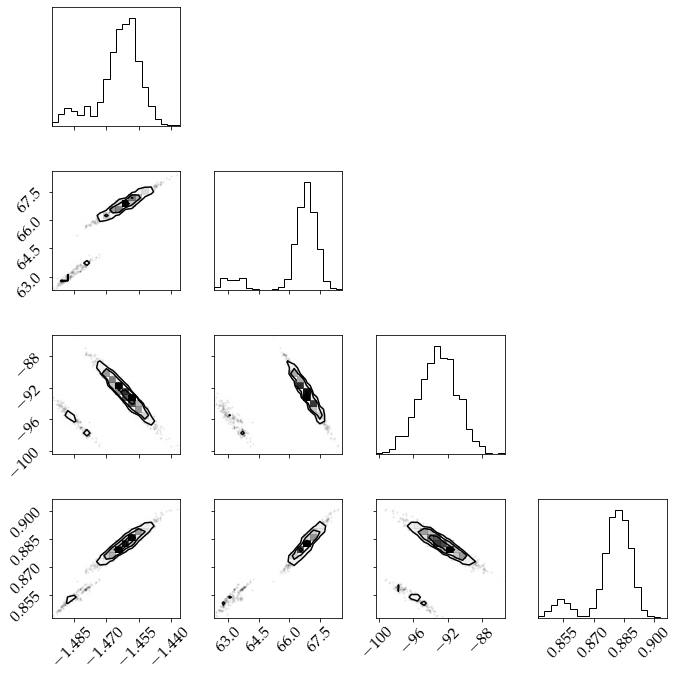

In [4]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
import corner

plt.figure(1)
corner.corner(samples);
plt.tight_layout()
fig = plt.gcf()
# fig.set_size_inches(6, 5)
plt.savefig('./test4.png',dpi=1200,format='png')

In [21]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

from models import elastic_MERT
from bayesian_wrapper import Etarget
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])

plt.figure(1)
inds = np.random.randint(len(samples), size=100)
for ind in inds:
    sample = samples[ind]
    if (elastic_MERT(sample,np.array([Etarget[-1]])>2e-20): print(sample)
    plt.plot(Etarget, elastic_MERT(sample,Etarget), 'C1', alpha=0.1,)
plt.plot(Etarget, elastic_MERT(theta_ref,Etarget),'--k',label="Haddad \& O'Malley")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma(\epsilon)$ ($m^2$)')
plt.legend()
# plt.ylim([1e-24, 3e-21])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(6, 5)
plt.savefig('./test5.1.png',dpi=1200,format='png')

TypeError: unsupported operand type(s) for /: 'list' and 'float'

<Figure size 432x288 with 0 Axes>

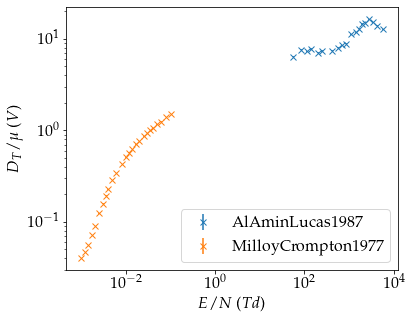

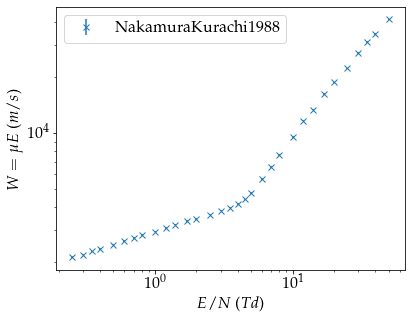

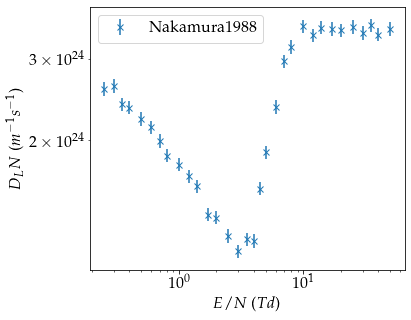

In [38]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

from bayesian_wrapper import expDatasets

plt.figure(1)
plt.errorbar(expDatasets[0].datasets[0].variables['E/N'],expDatasets[0].datasets[0].variables['DT/mu'],yerr=expDatasets[0].datasets[0].variables['DT/mu-rms'],fmt='x')
plt.errorbar(expDatasets[1].datasets[0].variables['E/N'],expDatasets[1].datasets[0].variables['DT/mu'],yerr=expDatasets[1].datasets[0].variables['DT/mu-rms'],fmt='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$D_T/\mu$ ($V$)')
plt.legend(['AlAminLucas1987','MilloyCrompton1977'],loc='lower right')
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(6, 5)
plt.savefig('./test1.png',dpi=1200,format='png')

plt.figure(2)
plt.errorbar(expDatasets[2].datasets[0].variables['E/N'],expDatasets[2].datasets[0].variables['W'],yerr=expDatasets[2].datasets[0].variables['W-rms'],fmt='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$W=\mu E$ ($m/s$)')
plt.legend(['NakamuraKurachi1988'],loc='upper left')
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(6, 5)
plt.savefig('./test2.png',dpi=1200,format='png')

plt.figure(3)
plt.errorbar(expDatasets[2].datasets[0].variables['E/N'],expDatasets[2].datasets[0].variables['DLN'],yerr=expDatasets[2].datasets[0].variables['DLN-rms'],fmt='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$D_LN$ ($m^{-1}s^{-1}$)');
plt.legend(['Nakamura1988'],loc='upper left')
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(6, 5)
plt.savefig('./test3.png',dpi=1200,format='png')

